# Pipes
A pipe is a unidirectional data channel in memory. One process writes to it, another reads from it. Think of it as a simple queue in kernel memory.

- A pipe is an inter-process communication (IPC) mechanism that provides a unidirectional data stream.
- One process writes to the pipe, and another process reads from it.
- Internally, the data is buffered by the kernel, so it does behave somewhat like a queue (FIFO).

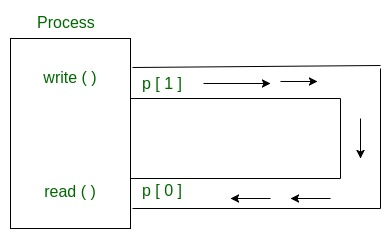

# Exampe: Child process sends a number 42 to the parent through a pipe

In [5]:
"""

p----Who------Action
1	Parent	Creates pipe (fd[0], fd[1])
2	Parent	fork() → creates child
3	Child	Closes read end (fd[0]) — doesn't need it
4	Child	Assigns a number to x
5	Child	Writes x to pipe (fd[1])
6	Child	Closes write end
7	Parent	Closes write end (fd[1]) — doesn't need it
8	Parent	Reads number from pipe (fd[0]) into y
9	Parent	Prints y

"""

"\n\np----Who------Action\n1\tParent\tCreates pipe (fd[0], fd[1])\n2\tParent\tfork() → creates child\n3\tChild\tCloses read end (fd[0]) — doesn't need it\n4\tChild\tAsks user for a number (x)\n5\tChild\tWrites x to pipe (fd[1])\n6\tChild\tCloses write end\n7\tParent\tCloses write end (fd[1]) — doesn't need it\n8\tParent\tReads number from pipe (fd[0]) into y\n9\tParent\tPrints y\n\n"

In [2]:
"""

Child Process                    Parent Process
     |                                 |
  [x = 42]                             |
     |                                 |
  write(fd[1])  ──────pipe──────→  read(fd[0])
     |                                 |
     |                              [y = 42]
     |                                 |
     └────────── "Got 42 from child" ←─┘
     
     
     """


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 3)

In [6]:
"""

Close---------------------Why
Child closes fd[0]--------Child only WRITES, doesn't read
Parent closes fd[1]-------Parent only READS, doesn't write


Good practice: Close unused ends to avoid confusion and prevent errors.

"""

"\n\nClose---------------------Why\nChild closes fd[0]--------Child only WRITES, doesn't read\nParent closes fd[1]-------Parent only READS, doesn't write\n\n\nGood practice: Close unused ends to avoid confusion and prevent errors.\n\n"

In [26]:
%%bash
cat <<EOF > code.c
#include <stdio.h>
#include <unistd.h>

#include <stdio.h>
#include <unistd.h>
#include <stdlib.h>

int main() {
    int fd[2];
    
    //fd[0] → file descriptor for reading from the pipe.

    //fd[1] → file descriptor for writing to the pipe.
    
    
    
    // Create the pipe
    int pipe_result = pipe(fd);
    
    if (pipe_result == -1) {
        printf("Pipe failed\n");
        return 1;
    }
    
    //printf("\nPipe value is: %d\n", pipe_result);
    
    
    int id = fork(); //Now we have 2 processes (parent and child), 
                     //both with access to the same pipe!


     
     
    // Just a check 
    if (id == -1) {
        printf("Fork failed\n");
        return 1;
    }
    
    
    // Now lets work with the child process
    if (id == 0) {
        // Child process
        close(fd[0]);  // Close read end for child. Child is not reading anything
        
        int x = 42;

        
        write(fd[1], &x, sizeof(int)); //Go to location &x, read 4 bytes, send them
        close(fd[1]);
    
    // #####This is important#######
    // Above the 42 flows from the childs x variable, through the pipe, and waits to be read:


    
    } 
    else {
        // Parent process
        close(fd[1]);  // Close write end. Parent is going to read not write
        
        int y;
        read(fd[0], &y, sizeof(int));
        close(fd[0]); // Now close read end too for the parent
        
        // ##### Again important #####
        // Above Parent Reads 42 from the Pipe into y and closes the read end

        
        printf("Got from child process: %d\n", y);
    }
    
    return 0;
}

EOF

gcc code.c -o code
./code

Got from child process: 42


# Homework: Make the parent process send a number back to the child process

 # Example: Array elements sum
 Now lets do a nice example which we have an array whose elements need to be summed up, in order to divide the task, half the elements get summed my parent process and half by the child
 

In [5]:
%%bash
cat <<EOF > code.c
#include <stdio.h>
#include <unistd.h>
#include <stdlib.h>
#include <sys/wait.h>

#define ARRAY_SIZE 10

int main() {
    int fd[2];
    int arr[ARRAY_SIZE] = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10};
    int half = ARRAY_SIZE / 2;  // 5 elements each
    
    int i;
    int parent_sum = 0;
    int child_sum = 0;
    int total_sum = 0;
    
    // Create the pipe for child to send its sum back to parent
    if (pipe(fd) == -1) {
        printf("Pipe failed!\n");
        return 1;
    }
    
    int id = fork();
    
    if (id == -1) {
        printf("Fork failed!\n");
        return 1;
    }
    
    // ============================================
    // CHILD PROCESS: Sums the SECOND half
    // ============================================
    if (id == 0) {
        close(fd[0]);  // Child won't read, only write
        
        // Child sums elements from half to end
        for (i = half; i < ARRAY_SIZE; i++) {
            child_sum += arr[i];
            printf(" Child: Added arr[%d] = %d, running sum: %d\n", 
                   i, arr[i], child_sum);
        }
        
        printf(" Child finished! My sum = %d\n", child_sum);
        
        // Send the child's sum to parent through the pipe
        write(fd[1], &child_sum, sizeof(int));
        close(fd[1]);
        
        printf(" Child sent %d to parent through pipe!\n", child_sum);
    }
    
    // ============================================
    // PARENT PROCESS: Sums the FIRST half
    // ============================================
    else {
        close(fd[1]);  // Parent won't write, only read
        
        // Parent sums elements from 0 to half-1
        for (i = 0; i < half; i++) {
            parent_sum += arr[i];
            printf(" Parent: Added arr[%d] = %d, running sum: %d\n", 
                   i, arr[i], parent_sum);
        }
        
        printf(" Parent finished! My sum = %d\n", parent_sum);
        
        // Wait for child to finish
        wait(NULL);
        
        // Read child's sum from the pipe
        read(fd[0], &child_sum, sizeof(int));
        close(fd[0]);
        
        printf("\n Parent received child's sum: %d\n", child_sum);
        
        // Calculate total
        total_sum = parent_sum + child_sum;
        
        printf("\n" "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" "\n");
        printf(" FINAL RESULT:\n");
        printf("   Parent sum (first %d elements): %d\n", half, parent_sum);
        printf("   Child sum  (last %d elements): %d\n", half, child_sum);
        printf("   TOTAL SUM of all %d elements: %d\n", ARRAY_SIZE, total_sum);
        printf("=" "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" " " "=" "\n");
        
        // Verify it's correct
        int verify = 0;
        for (i = 0; i < ARRAY_SIZE; i++) verify += arr[i];
        printf(" Verification (loop sum): %d\n", verify);
    }
    
    return 0;
}

EOF

gcc code.c -o code
./code

 Child: Added arr[5] = 6, running sum: 6
 Child: Added arr[6] = 7, running sum: 13
 Child: Added arr[7] = 8, running sum: 21
 Child: Added arr[8] = 9, running sum: 30
 Child: Added arr[9] = 10, running sum: 40
 Child finished! My sum = 40
 Child sent 40 to parent through pipe!
 Parent: Added arr[0] = 1, running sum: 1
 Parent: Added arr[1] = 2, running sum: 3
 Parent: Added arr[2] = 3, running sum: 6
 Parent: Added arr[3] = 4, running sum: 10
 Parent: Added arr[4] = 5, running sum: 15
 Parent finished! My sum = 15

 Parent received child's sum: 40

= = = = = = = = = = =
 FINAL RESULT:
   Parent sum (first 5 elements): 15
   Child sum  (last 5 elements): 40
   TOTAL SUM of all 10 elements: 55
== = = = = = = = = = =
 Verification (loop sum): 55


# Signals

Signals are like emergency messages the kernel sends to a process. Think of them as shouting "HEY!" at a running program to get its attention.



## Linux Signals Reference Table

| # | Signal Name | Default Action | Comment | POSIX |
|---|-------------|----------------|---------|-------|
| 1 | SIGHUP | Terminate | Hang up controlling terminal or process | Yes |
| 2 | SIGINT | Terminate | Interrupt from keyboard (Ctrl+C) | Yes |
| 3 | SIGQUIT | Dump | Quit from keyboard (Ctrl+\) | Yes |
| 4 | SIGILL | Dump | Illegal instruction | Yes |
| 5 | SIGTRAP | Dump | Breakpoint for debugging | No |
| 6 | SIGABRT | Dump | Abnormal termination | Yes |
| 6 | SIGIOT | Dump | Equivalent to SIGABRT | No |
| 7 | SIGBUS | Dump | Bus error | No |
| 8 | SIGFPE | Dump | Floating-point exception | Yes |
| 9 | SIGKILL | Terminate | Forced process termination (cannot be caught) | Yes |
| 10 | SIGUSR1 | Terminate | Available for user-defined purposes | Yes |
| 11 | SIGSEGV | Dump | Invalid memory reference (segmentation fault) | Yes |
| 12 | SIGUSR2 | Terminate | Available for user-defined purposes | Yes |
| 13 | SIGPIPE | Terminate | Write to pipe with no readers | Yes |
| 14 | SIGALRM | Terminate | Real-timer clock | Yes |
| 15 | SIGTERM | Terminate | Process termination (graceful) | Yes |
| 16 | SIGSTKFLT | Terminate | Coprocessor stack error | No |
| 17 | SIGCHLD | Ignore | Child process stopped or terminated | Yes |
| 18 | SIGCONT | Continue | Resume execution if stopped | Yes |
| 19 | SIGSTOP | Stop | Stop process execution (cannot be caught) | Yes |
| 20 | SIGTSTP | Stop | Stop process issued from tty (Ctrl+Z) | Yes |
| 21 | SIGTTIN | Stop | Background process requires input | Yes |
| 22 | SIGTTOU | Stop | Background process requires output | Yes |
| 23 | SIGURG | Ignore | Urgent condition on socket | No |
| 24 | SIGXCPU | Dump | CPU time limit exceeded | No |
| 25 | SIGXFSZ | Dump | File size limit exceeded | No |
| 26 | SIGVTALRM | Terminate | Virtual timer clock | No |
| 27 | SIGPROF | Terminate | Profile timer clock | No |
| 28 | SIGWINCH | Ignore | Window resizing | No |
| 29 | SIGIO | Terminate | I/O now possible | No |
| 29 | SIGPOLL | Terminate | Equivalent to SIGIO | No |
| 30 | SIGPWR | Terminate | Power supply failure | No |
| 31 | SIGSYS | Dump | Bad system call | No |
| 31 | SIGUNUSED | Dump | Equivalent to SIGSYS | No |


# Now lets do a few examples to put signals in action.


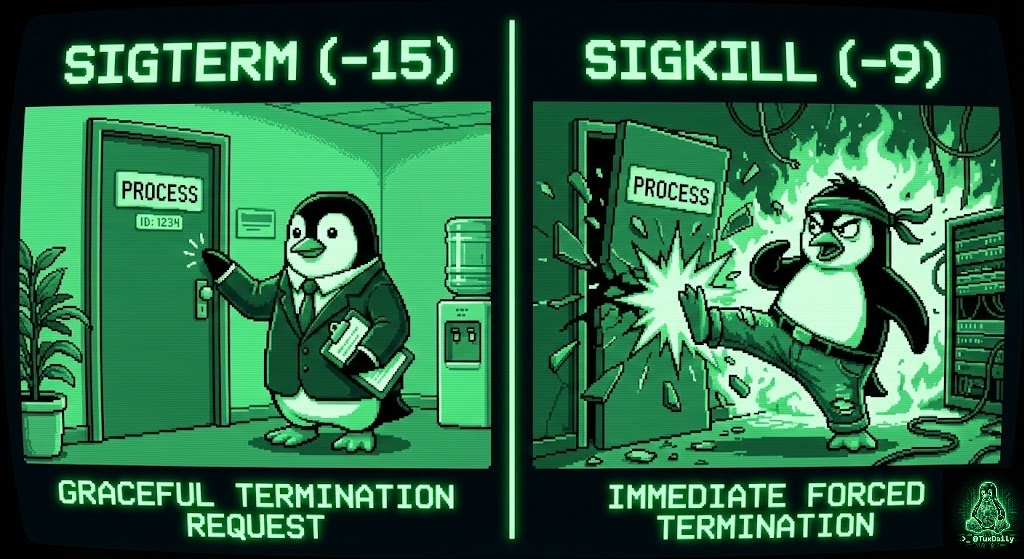

# Example: SIGTERM

In [15]:
%%bash
cat <<EOF > code_sigterm_example.c

#include <stdio.h>
#include <unistd.h>
#include <signal.h>

int main() {
    printf("log: Process ID is %d\n", getpid());
    printf("Running in an infinite loop...\n");
    printf("To kill me, run: kill -9 %d in another terminal\n\n", getpid());
    
    int count = 0;
    while (1) {
        printf("Alive... count: %d\n", count++);
        sleep(1);
    }
    
    return 0;
}

EOF

gcc code_sigterm_example.c -o code_sigterm_example
./code_sigterm_example

bash: line 24: 416278 Killed                  ./code_sigterm_example


CalledProcessError: Command 'b'cat <<EOF > code_sigterm_example.c\n\n#include <stdio.h>\n#include <unistd.h>\n#include <signal.h>\n\nint main() {\n    printf("log: Process ID is %d\\n", getpid());\n    printf("Running in an infinite loop...\\n");\n    printf("To kill me, run: kill -9 %d in another terminal\\n\\n", getpid());\n    \n    int count = 0;\n    while (1) {\n        printf("Alive... count: %d\\n", count++);\n        sleep(1);\n    }\n    \n    return 0;\n}\n\nEOF\n\ngcc code_sigterm_example.c -o code_sigterm_example\n./code_sigterm_example\n'' returned non-zero exit status 137.

======================================================================================

Above we have an infinite while loop so the code keeps on executing. In order to kill it, lets use the sigterm signal in the terminal. First we find the pid of the **`./code_sigterm_example`** and then kill it.

In the terminal do:

**`ps aux | grep "./code_sigterm_example"`**

and then:

kill -15 `<PID>`

This kill the process gracefully


# Example: SIGKILL

# Now lets kill the process more brutally !!!!


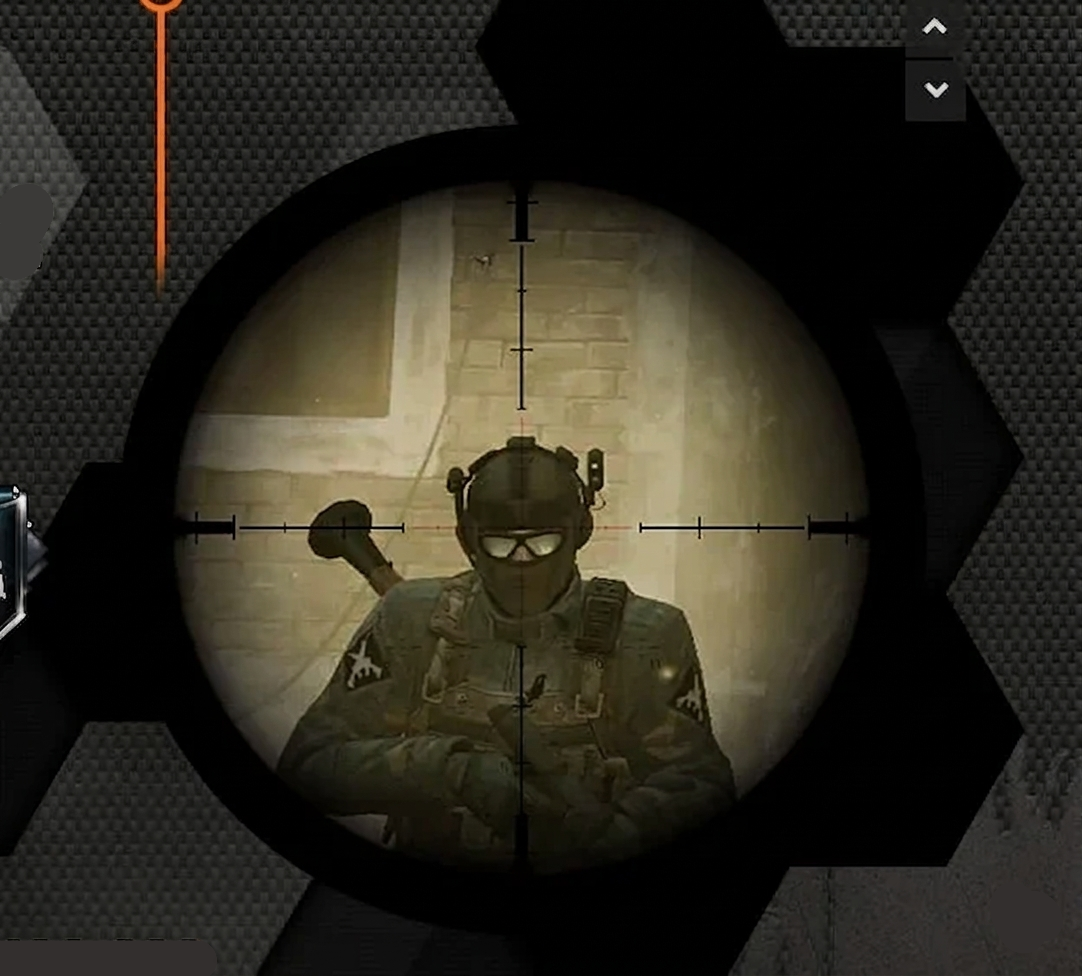


In [10]:
%%bash
cat <<EOF > code_sigkill_example.c

#include <stdio.h>
#include <unistd.h>
#include <signal.h>

int main() {
    printf("log: Process ID is %d\n", getpid());
    printf("Running in an infinite loop...\n");
    printf("To kill me, run: kill -9 %d in another terminal\n\n", getpid());
    
    int count = 0;
    while (1) {
        printf("Alive... count: %d\n", count++);
        sleep(1);
    }
    
    return 0;
}

EOF

gcc code_sigkill_example.c -o code_sigkill_example
./code_sigkill_example

bash: line 24: 412915 Killed                  ./code_sigkill_example


CalledProcessError: Command 'b'cat <<EOF > code_sigkill_example.c\n\n#include <stdio.h>\n#include <unistd.h>\n#include <signal.h>\n\nint main() {\n    printf("log: Process ID is %d\\n", getpid());\n    printf("Running in an infinite loop...\\n");\n    printf("To kill me, run: kill -9 %d in another terminal\\n\\n", getpid());\n    \n    int count = 0;\n    while (1) {\n        printf("Alive... count: %d\\n", count++);\n        sleep(1);\n    }\n    \n    return 0;\n}\n\nEOF\n\ngcc code_sigkill_example.c -o code_sigkill_example\n./code_sigkill_example\n'' returned non-zero exit status 137.

Above we have an infinite while loop so the code keeps on executing. In order to kill it, lets use the sigkill signal in the terminal. First we find the pid of the **`./code_sigkill_example`**  and then kill it.

In the terminal do:

**`ps aux | grep "./code_sigkill_example"`** 

and then: 

**`kill -9 <PID>`**
